In [1]:
import os
import gc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [2]:
TEST_DATA_PATH = r'D:\Major Project\SpamX\machine_learning\dataset\test.csv'
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
MODELS = {
    "MuRIL": r"D:\Major Project\SpamX\machine_learning\models\MuRIL\final_muril_calibrated1",
    "XLMR": r"D:\Major Project\SpamX\machine_learning\models\XLM_Roberta\final_xlm_roberta_calibrated1",
    "IndicBERT": r"D:\Major Project\SpamX\machine_learning\models\IndicBERT\final_indicbert",
    "mBERT": r"D:\Major Project\SpamX\machine_learning\models\mBERT\final_mbert"
}

In [4]:
def get_predictions_sliding_window(model_path, df, batch_size=16):
    print(f"Processing: {model_path}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_path, num_labels=2, trust_remote_code=True
    ).to(DEVICE)
    model.eval()

    all_final_probs = []

    for i in range(0, len(df), batch_size):
        batch_text = df['Comment'].iloc[i:i+batch_size].astype(str).tolist()
        
        inputs = tokenizer(
            batch_text,
            truncation=True,
            max_length=128,
            stride=32,
            return_overflowing_tokens=True,
            padding="max_length",
            return_tensors="pt"
        ).to(DEVICE)
        
        sample_mapping = inputs.pop("overflow_to_sample_mapping")

        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            spam_probs = probs[:, 1]
            
        batch_results = {idx: [] for idx in range(len(batch_text))}
        for slice_idx, original_idx in enumerate(sample_mapping):
            batch_results[original_idx.item()].append(spam_probs[slice_idx])
            
        for idx in range(len(batch_text)):
            all_final_probs.append(max(batch_results[idx]))

    del model, tokenizer, inputs
    torch.cuda.empty_cache()
    gc.collect()
    
    probs_final = np.array(all_final_probs)
    preds_final = (probs_final > 0.5).astype(int)
    return preds_final, probs_final

In [5]:
test_df = pd.read_csv(TEST_DATA_PATH)
y_true = test_df['Label'].values
all_results = {}

for name, path in MODELS.items():
    try:
        y_pred, y_prob = get_predictions_sliding_window(path, test_df)
        all_results[name] = {"pred": y_pred, "prob": y_prob}
    except Exception as e:
        print(f"Error with {name}: {e}")

Processing: D:\Major Project\SpamX\machine_learning\models\MuRIL\final_muril_calibrated1
Processing: D:\Major Project\SpamX\machine_learning\models\XLM_Roberta\final_xlm_roberta_calibrated1
Processing: D:\Major Project\SpamX\machine_learning\models\IndicBERT\final_indicbert
Processing: D:\Major Project\SpamX\machine_learning\models\mBERT\final_mbert


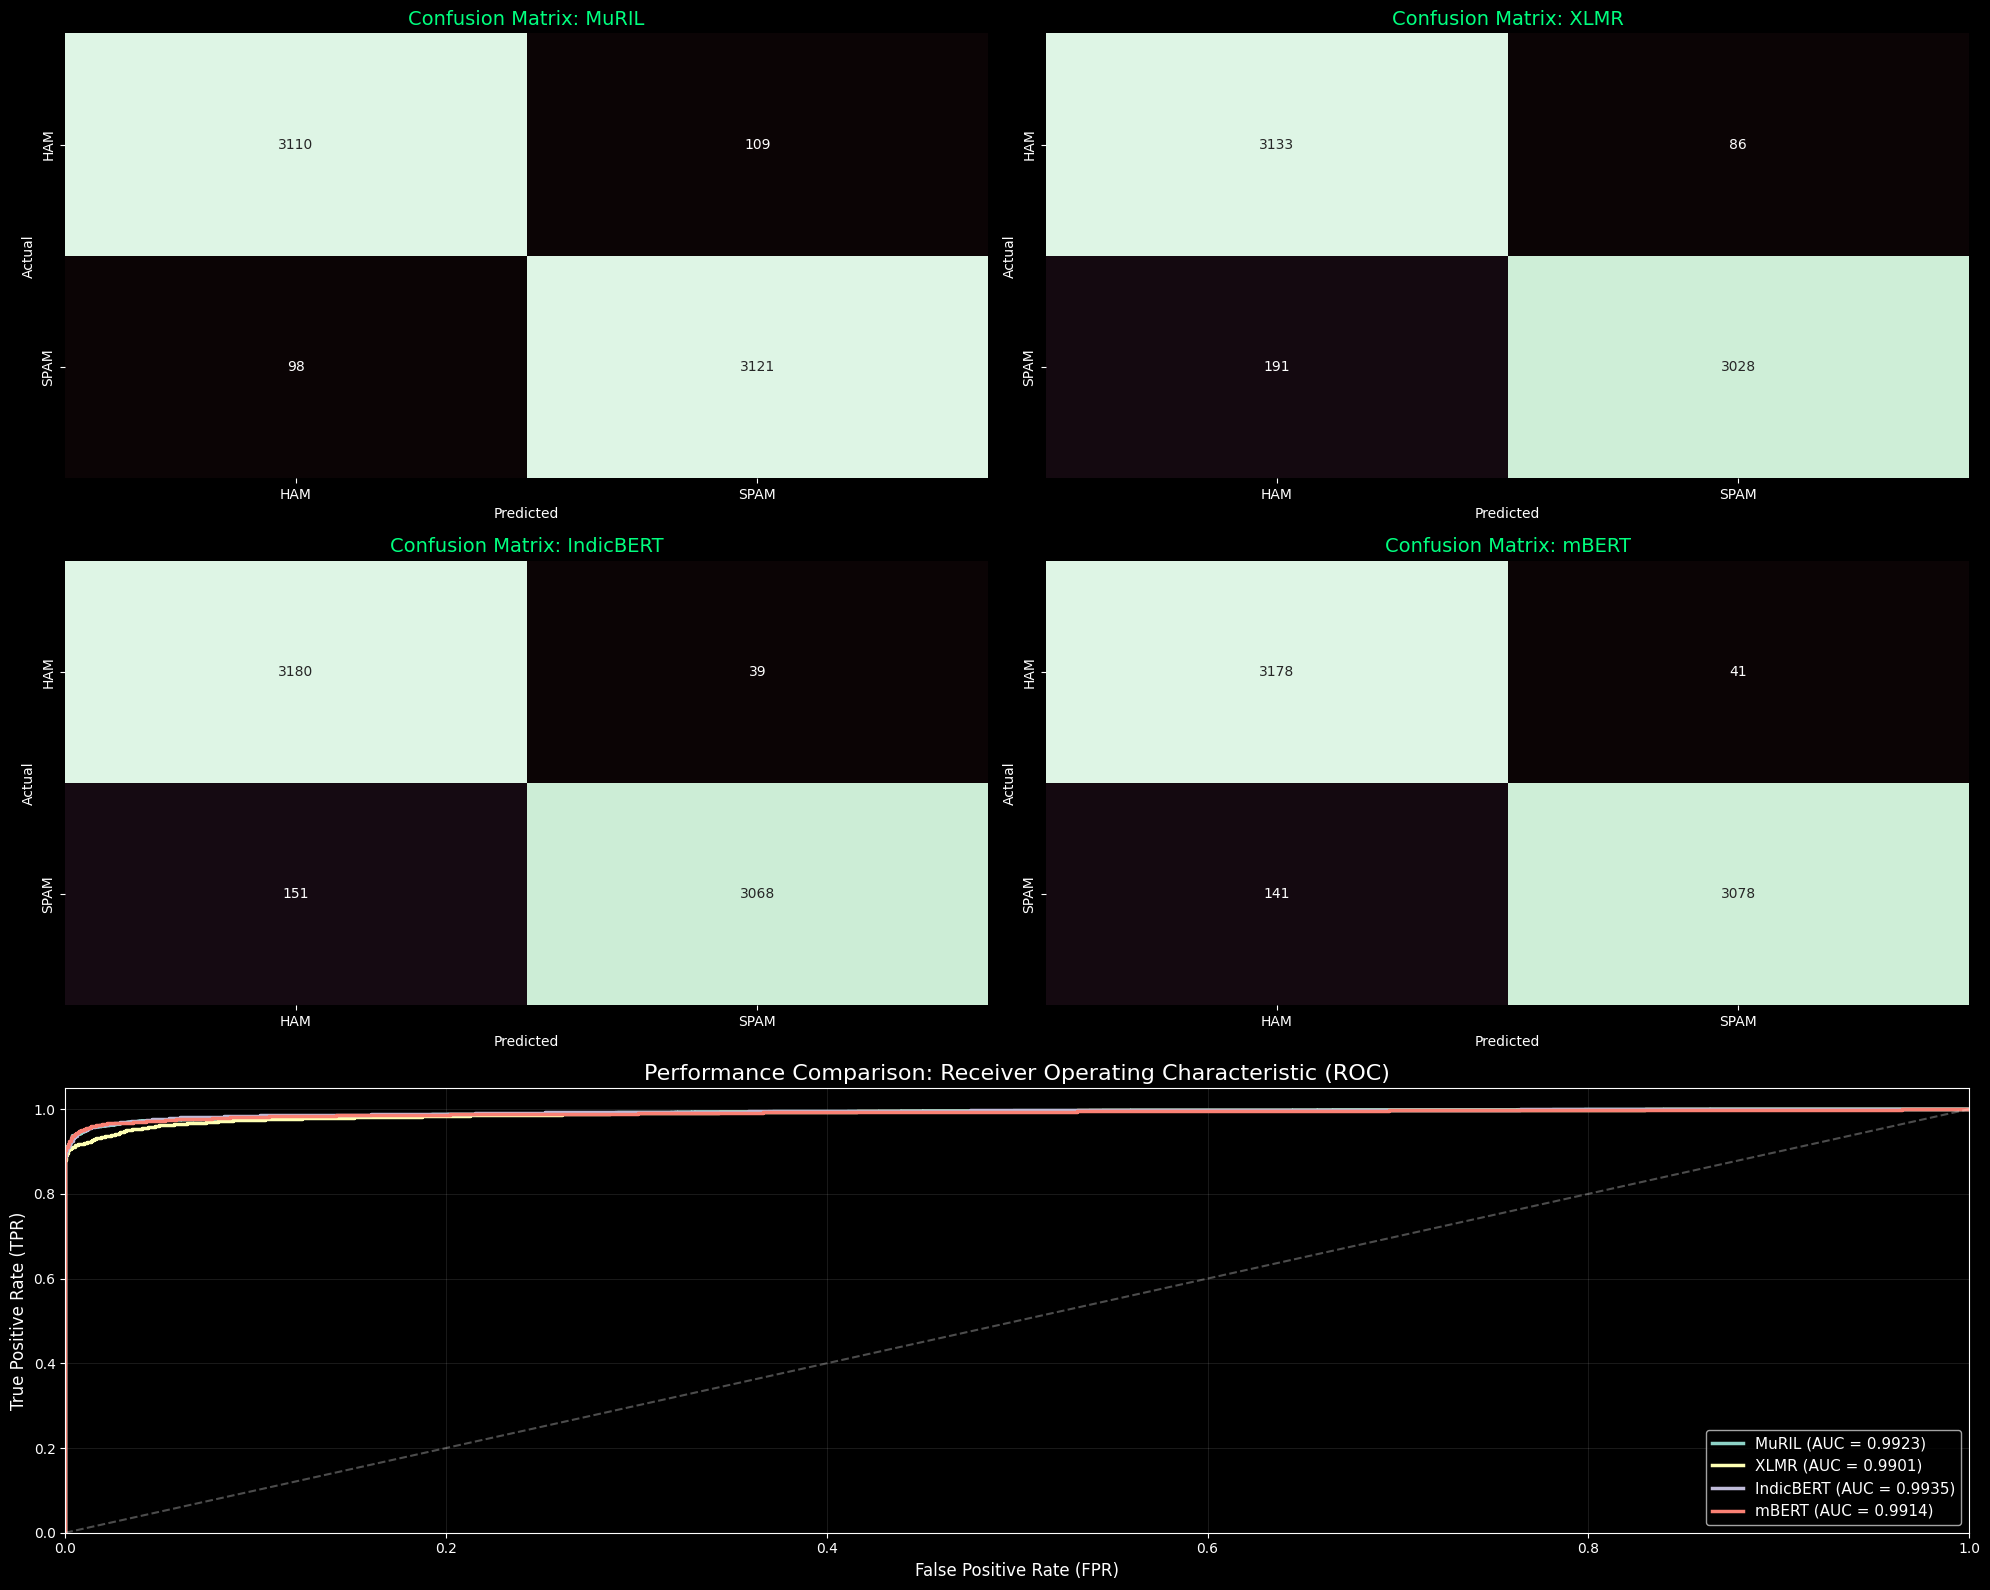


FINAL CONSOLIDATED PERFORMANCE REPORT
    Model  Accuracy  F1 (Spam)  F1 (Ham)  Precision (Spam)  Recall (Spam)
    MuRIL  0.967847   0.967902  0.967792          0.966254       0.969556
     XLMR  0.956974   0.956261  0.957665          0.972383       0.940665
IndicBERT  0.970488   0.969965  0.970992          0.987448       0.953091
    mBERT  0.971730   0.971284  0.972163          0.986855       0.956198


In [6]:
plt.style.use('dark_background')
fig = plt.figure(figsize=(20, 16))

for i, (name, data) in enumerate(all_results.items()):
    plt.subplot(3, 2, i+1)
    cm = confusion_matrix(y_true, data["pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako', 
                xticklabels=['HAM', 'SPAM'], yticklabels=['HAM', 'SPAM'], cbar=False)
    plt.title(f"Confusion Matrix: {name}", fontsize=14, color='springgreen')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.subplot(3, 1, 3)
for name, data in all_results.items():
    fpr, tpr, _ = roc_curve(y_true, data["prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='white', linestyle='--', alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Performance Comparison: Receiver Operating Characteristic (ROC)', fontsize=16)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.1)

plt.tight_layout()
plt.savefig("SpamX_Report.png", dpi=300)
plt.show()

print("\n" + "="*60)
print("FINAL CONSOLIDATED PERFORMANCE REPORT")
print("="*60)
metrics_list = []
for name, data in all_results.items():
    rep = classification_report(y_true, data["pred"], output_dict=True)
    metrics_list.append({
        "Model": name,
        "Accuracy": rep['accuracy'],
        "F1 (Spam)": rep['1']['f1-score'],
        "F1 (Ham)": rep['0']['f1-score'],
        "Precision (Spam)": rep['1']['precision'],
        "Recall (Spam)": rep['1']['recall']
    })

print(pd.DataFrame(metrics_list).to_string(index=False))


In [1]:
import os
import gc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [2]:
TEST_DATA_PATH = r'D:\Major Project\SpamX\machine_learning\dataset\test.csv'
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
MODELS = {
    "MuRIL": r"D:\Major Project\SpamX\machine_learning\models\MuRIL\final_muril_calibrated1",
    "XLM_RoBERTa": r"D:\Major Project\SpamX\machine_learning\models\XLM_Roberta\final_xlm_roberta_calibrated1"
}

In [4]:
def get_predictions_sliding_window(model_path, df, batch_size=12):
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_path, num_labels=2, trust_remote_code=True
    ).to(DEVICE)
    model.eval()

    all_final_probs = []
    for i in range(0, len(df), batch_size):
        batch_text = df['Comment'].iloc[i:i+batch_size].astype(str).tolist()
        inputs = tokenizer(
            batch_text, truncation=True, max_length=128, stride=32,
            return_overflowing_tokens=True, padding="max_length", return_tensors="pt"
        ).to(DEVICE)
        
        sample_mapping = inputs.pop("overflow_to_sample_mapping")
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()[:, 1]
            
        batch_results = {idx: [] for idx in range(len(batch_text))}
        for slice_idx, original_idx in enumerate(sample_mapping):
            batch_results[original_idx.item()].append(probs[slice_idx])
            
        for idx in range(len(batch_text)):
            all_final_probs.append(max(batch_results[idx]))

    del model, tokenizer
    torch.cuda.empty_cache()
    gc.collect()
    return np.array(all_final_probs)

In [5]:
test_df = pd.read_csv(TEST_DATA_PATH)
y_true = test_df['Label'].values
results = {}

for name, path in MODELS.items():
    print(f"Analyzing {name}...")
    y_prob = get_predictions_sliding_window(path, test_df)
    y_pred = (y_prob > 0.5).astype(int)
    results[name] = {"pred": y_pred, "prob": y_prob}

Analyzing MuRIL...
Analyzing XLM_RoBERTa...


In [6]:
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

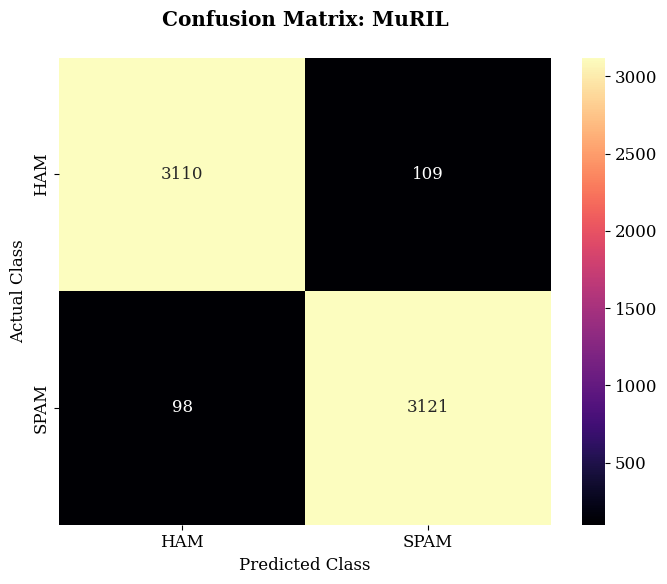

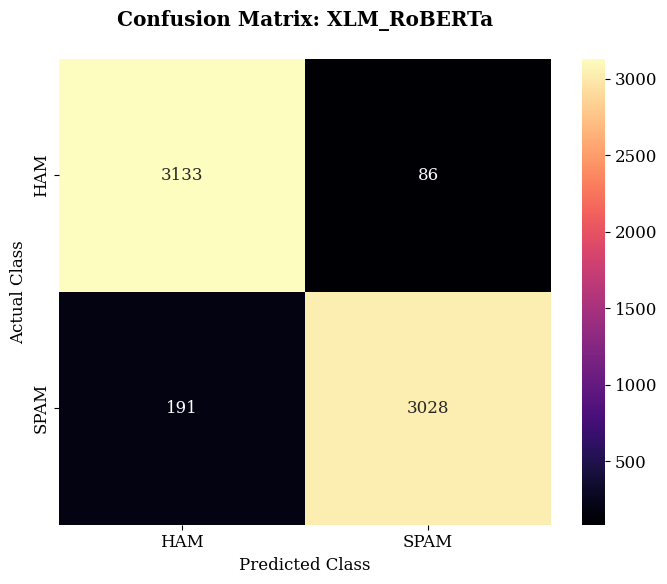

In [12]:
for name, data in results.items():
    plt.figure(figsize=(7, 6))
    cm = confusion_matrix(y_true, data["pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', cbar=True,
                xticklabels=['HAM', 'SPAM'], yticklabels=['HAM', 'SPAM'])
    plt.title(f"Confusion Matrix: {name}\n", fontweight='bold')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.savefig(f"CM_{name.split()[0]}.pdf")
    plt.show()

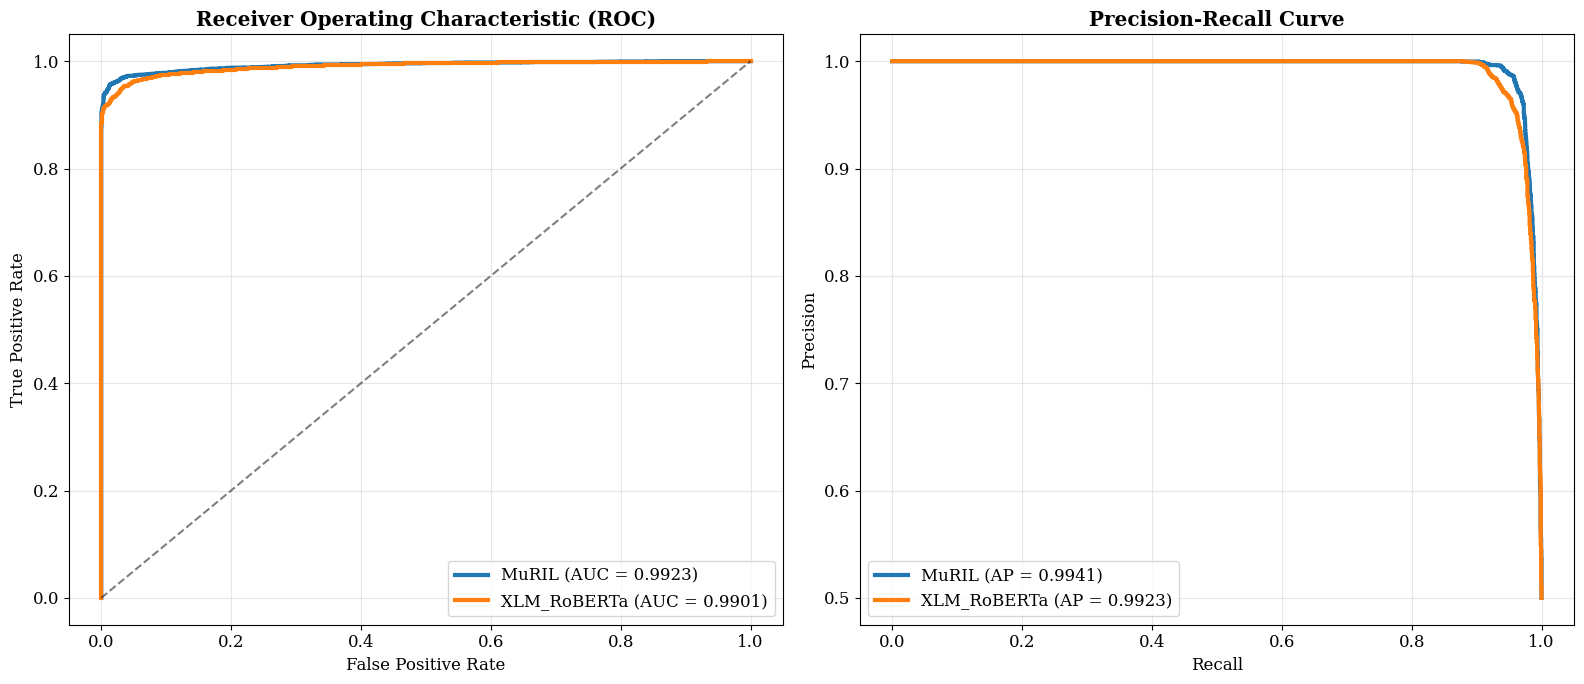

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
for name, data in results.items():
    fpr, tpr, _ = roc_curve(y_true, data["prob"])
    ax1.plot(fpr, tpr, lw=3, label=f'{name} (AUC = {auc(fpr, tpr):.4f})')

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

for name, data in results.items():
    precision, recall, _ = precision_recall_curve(y_true, data["prob"])
    ap = average_precision_score(y_true, data["prob"])
    ax2.plot(recall, precision, lw=3, label=f'{name} (AP = {ap:.4f})')

ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("SpamX_Performance_Curves.pdf")
plt.show()

In [14]:
for name, data in results.items():
    print(f"\n{name.upper()} STATISTICAL ANALYSIS")
    print(classification_report(y_true, data["pred"], target_names=['Ham', 'Spam'], digits=4))


MURIL STATISTICAL ANALYSIS
              precision    recall  f1-score   support

         Ham     0.9695    0.9661    0.9678      3219
        Spam     0.9663    0.9696    0.9679      3219

    accuracy                         0.9678      6438
   macro avg     0.9679    0.9678    0.9678      6438
weighted avg     0.9679    0.9678    0.9678      6438


XLM_ROBERTA STATISTICAL ANALYSIS
              precision    recall  f1-score   support

         Ham     0.9425    0.9733    0.9577      3219
        Spam     0.9724    0.9407    0.9563      3219

    accuracy                         0.9570      6438
   macro avg     0.9575    0.9570    0.9570      6438
weighted avg     0.9575    0.9570    0.9570      6438



Calibrated version testing

In [6]:
import os
import gc
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [7]:
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

In [8]:
TEST_DATA_PATH = r'D:\Major Project\SpamX\machine_learning\dataset\test.csv'
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODELS = {
    "MuRIL": r"D:\machine_learning\models\MuRIL\final_muril_calibrated1_v2",
    "XLM-RoBERTa": r"D:\machine_learning\models\XLM_Roberta\final_xlm_roberta_calibrated1_v2"
}

In [9]:
def get_probs(model_path, df, batch_size=12):
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    model = AutoModelForSequenceClassification.from_pretrained(model_path).to(DEVICE)
    model.eval()
    
    probs = []
    for i in range(0, len(df), batch_size):
        batch = df['Comment'].iloc[i:i+batch_size].astype(str).tolist()
        inputs = tokenizer(batch, truncation=True, max_length=128, padding="max_length", return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs.extend(torch.softmax(logits, dim=1).cpu().numpy()[:, 1])
            
    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    return np.array(probs)

In [10]:
test_df = pd.read_csv(TEST_DATA_PATH)
y_true = test_df['Label'].values
results = {}

for name, path in MODELS.items():
    print(f"Running: {name}...")
    y_prob = get_probs(path, test_df)
    results[name] = {"prob": y_prob, "pred": (y_prob > 0.5).astype(int)}

Running: MuRIL...
Running: XLM-RoBERTa...


In [11]:
results["Ensemble"] = {
    "prob": (results["MuRIL"]["prob"] * 0.5) + (results["XLM-RoBERTa"]["prob"] * 0.5),
}
results["Ensemble"]["pred"] = (results["Ensemble"]["prob"] > 0.5).astype(int)

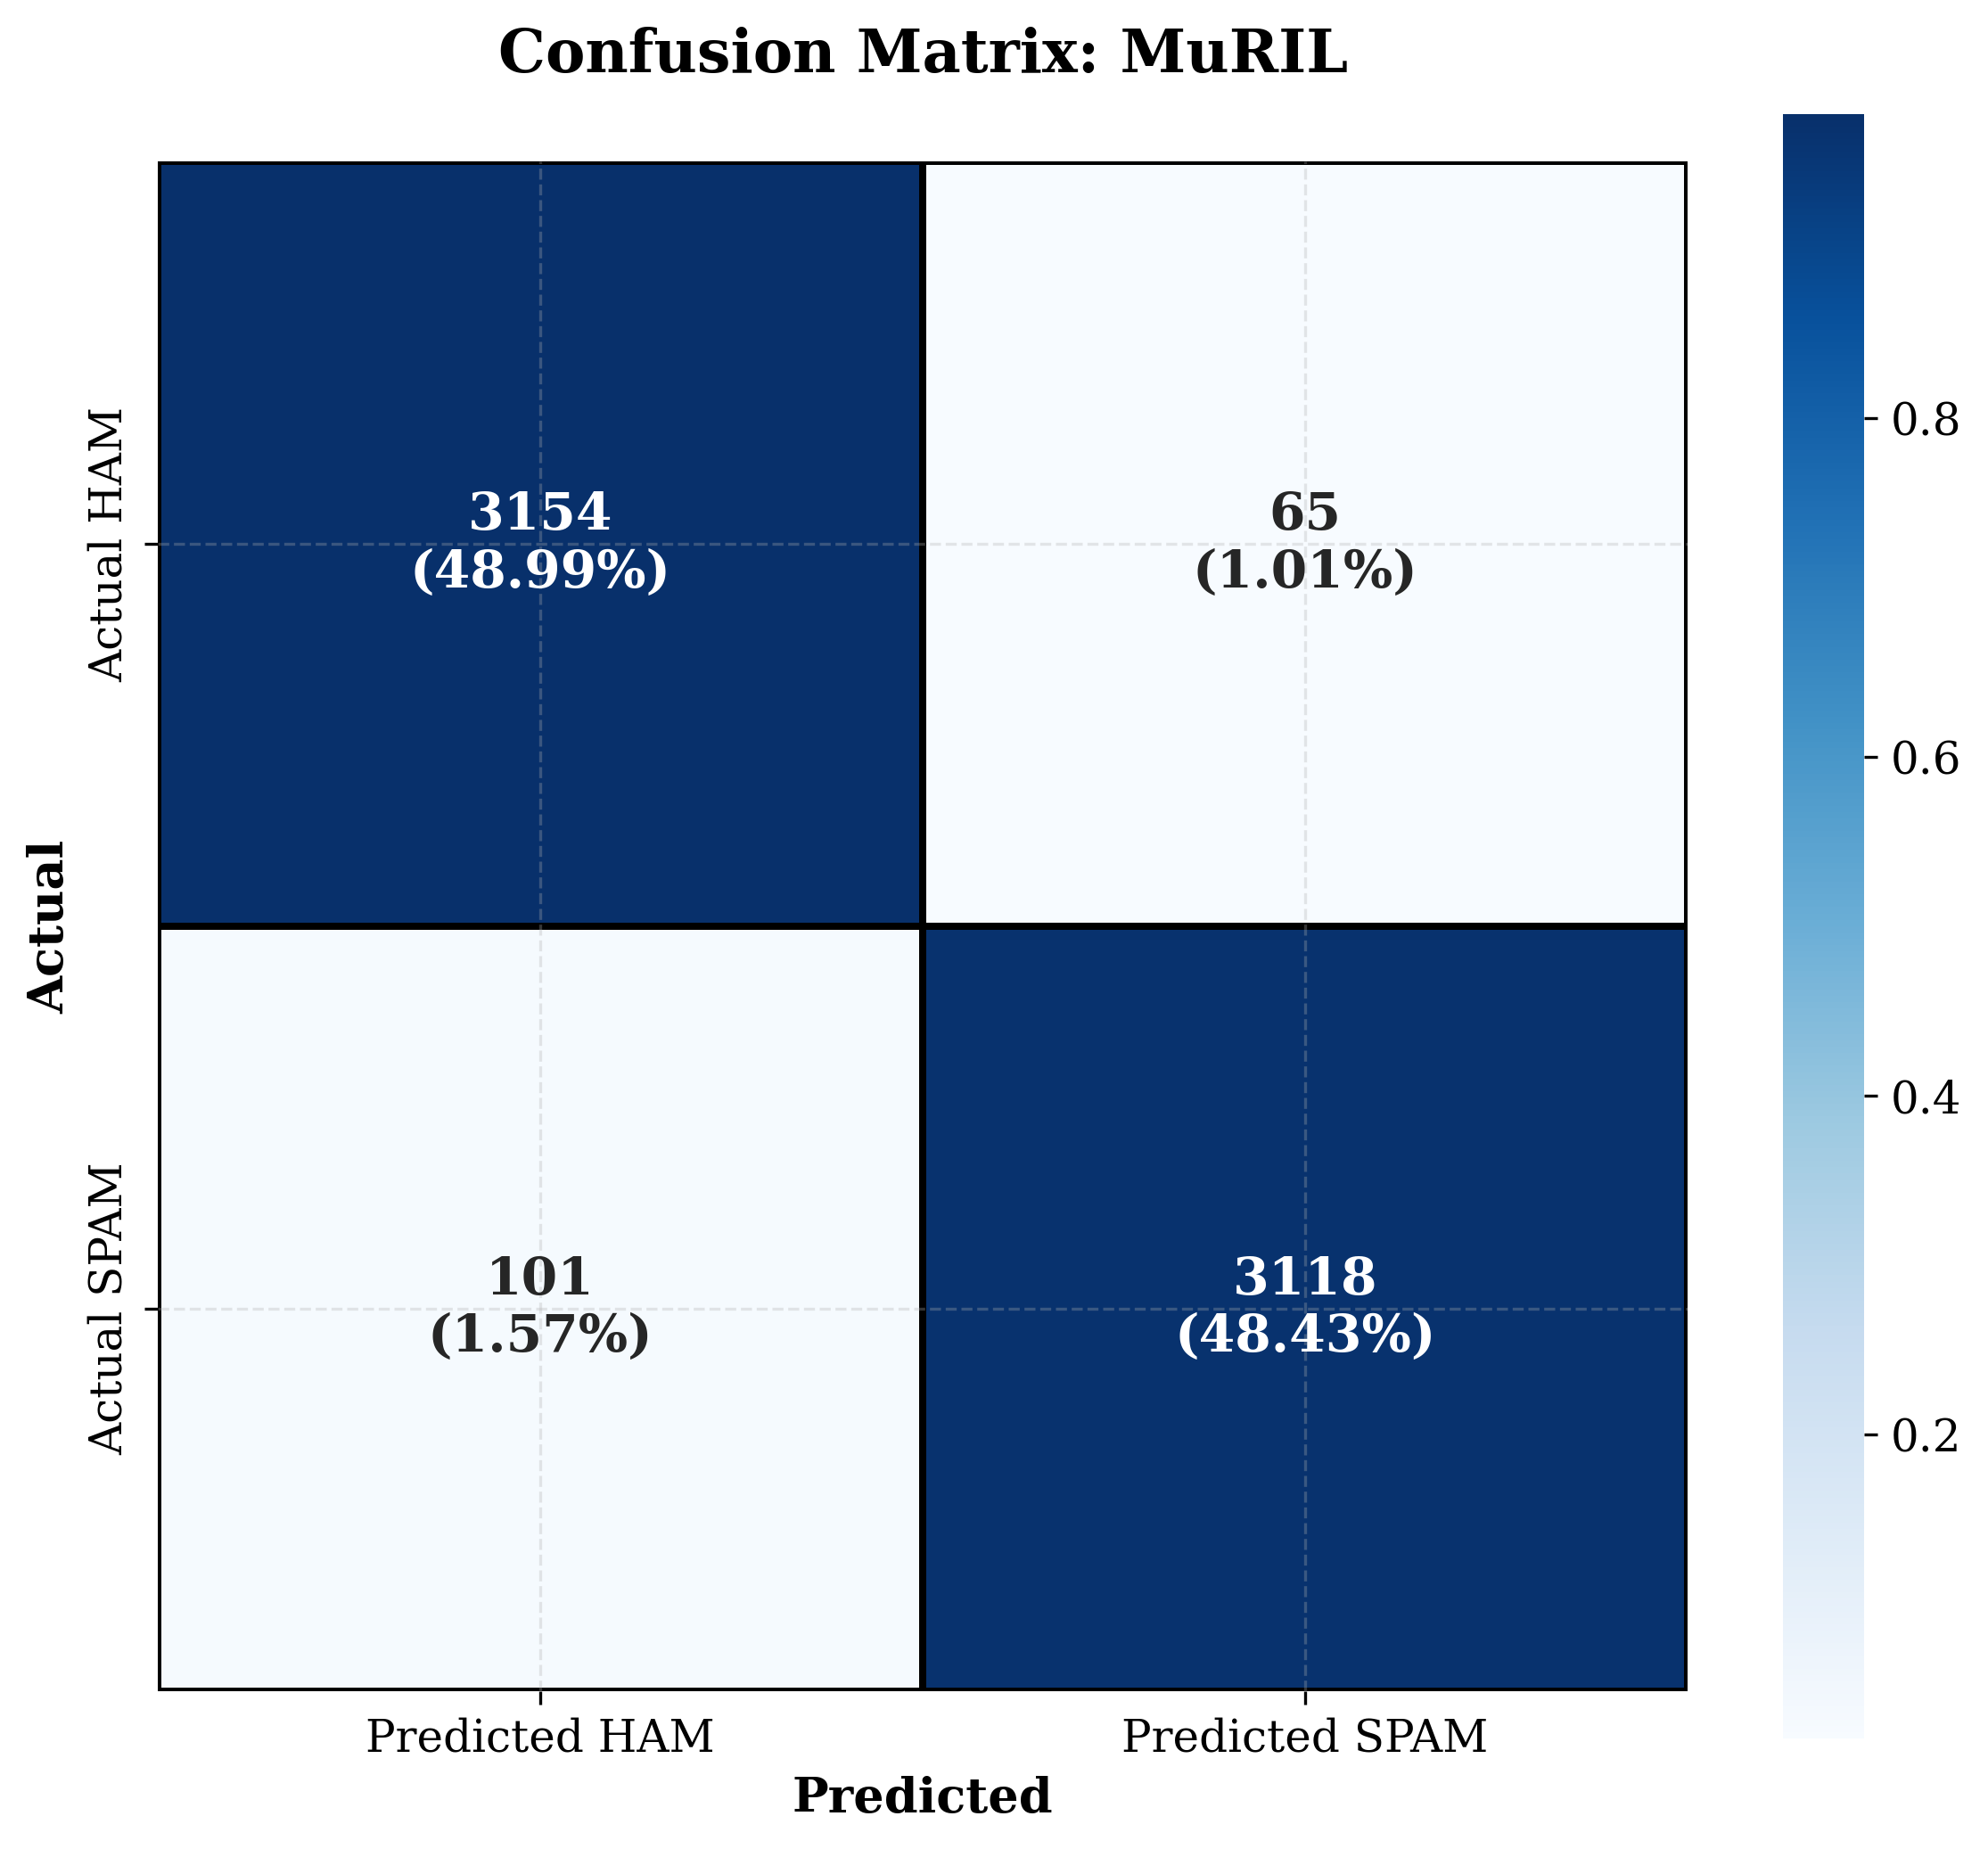

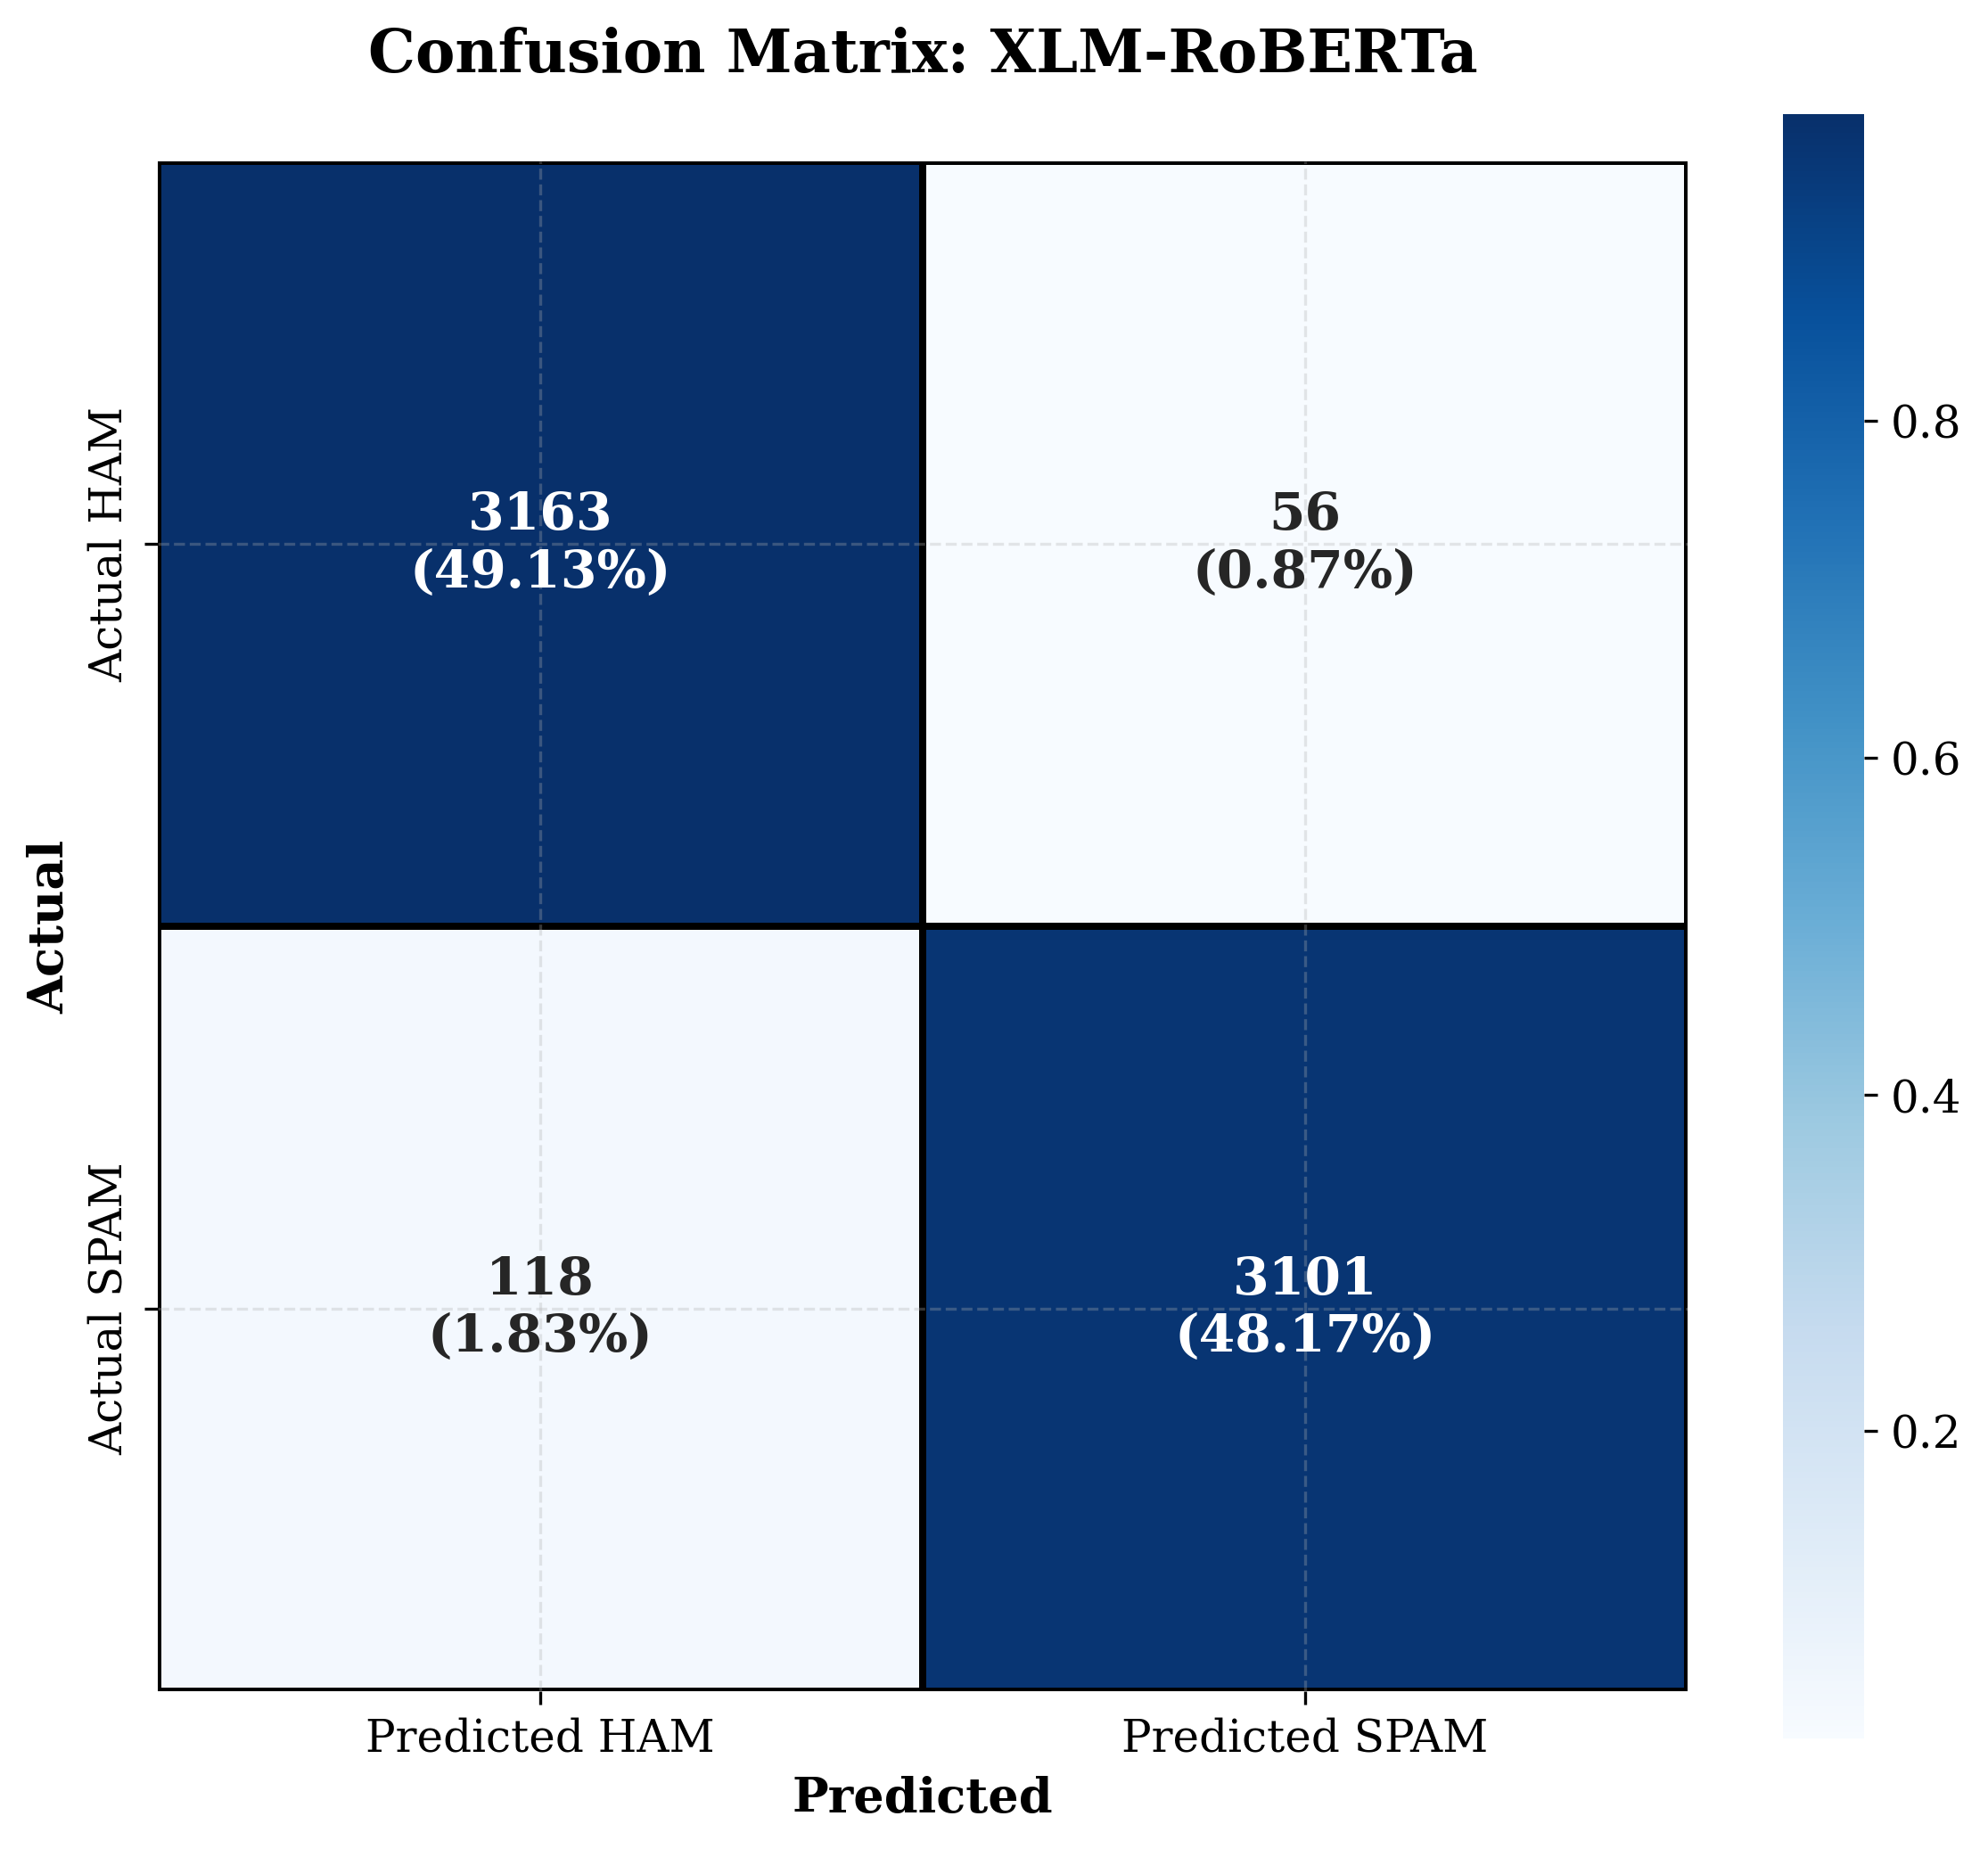

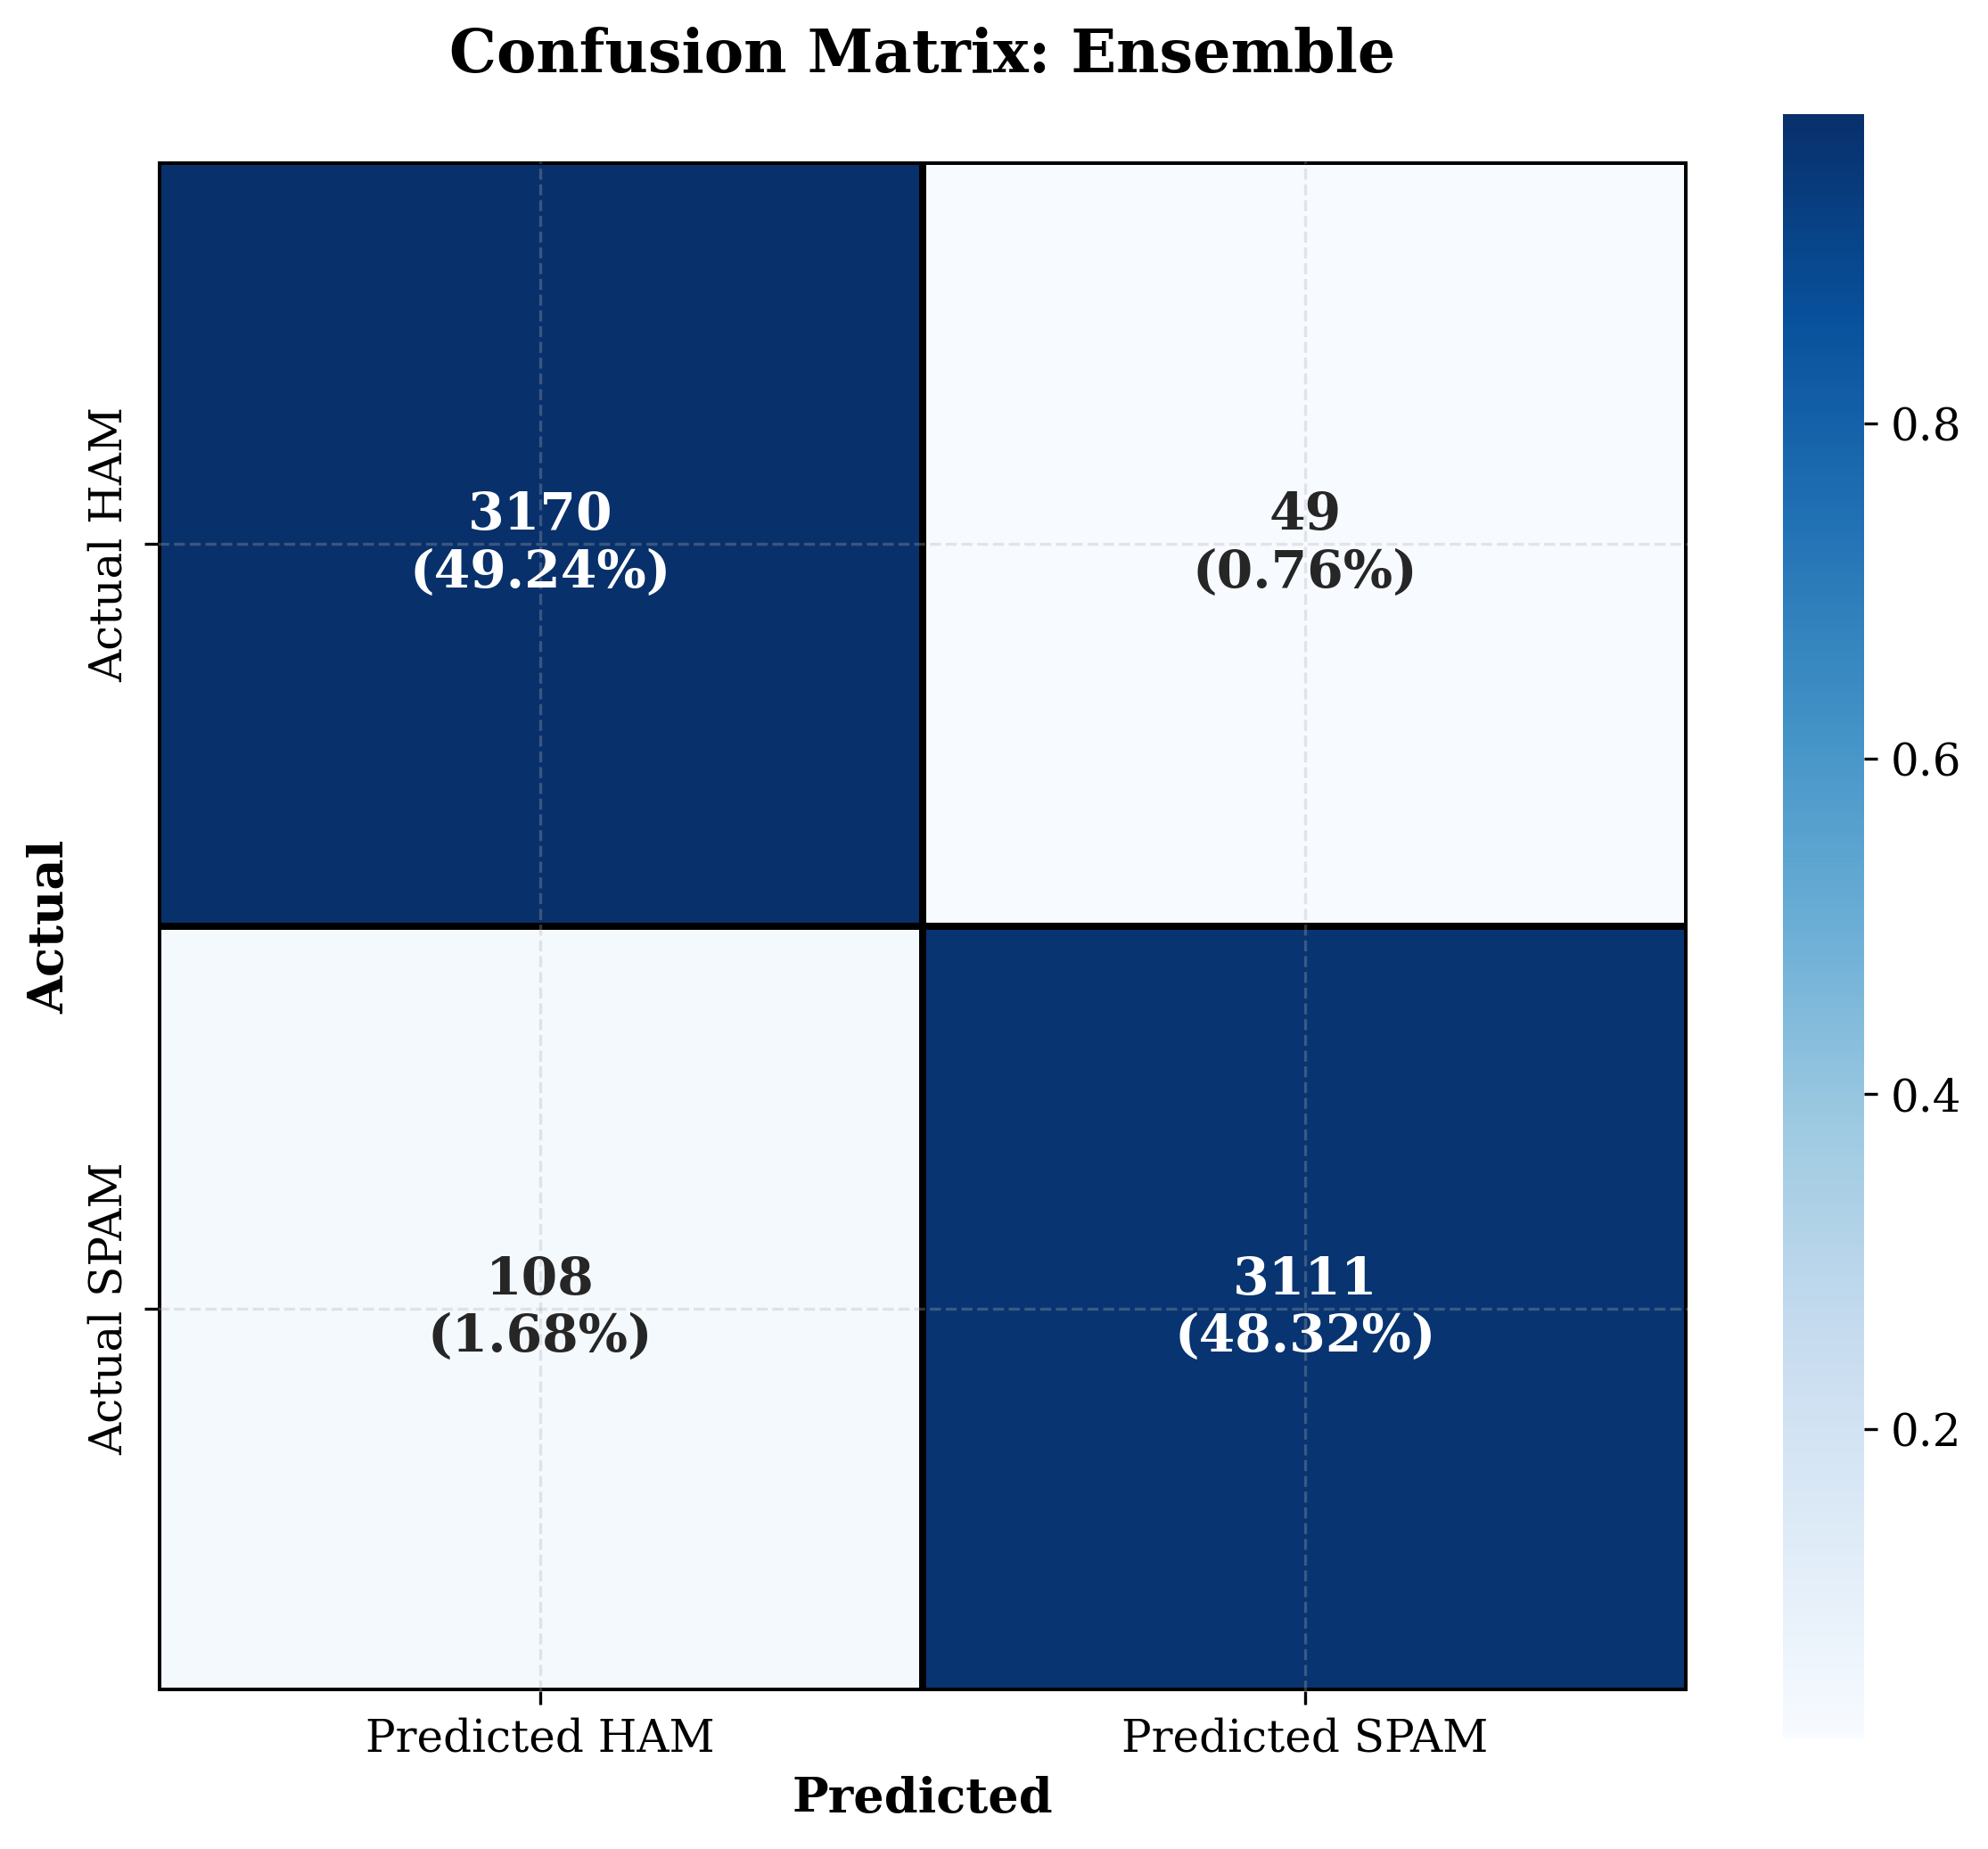

In [12]:
def plot_professional_cm(y_true, y_pred, name):
    plt.figure(figsize=(8, 7))
    cm = confusion_matrix(y_true, y_pred)
    
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    total_samples = np.sum(cm)
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["({0:.2%})".format(value) for value in cm.flatten()/total_samples]
    
    labels = [f"{c}\n{p}" for c, p in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    sns.heatmap(cm_normalized, annot=labels, fmt="", cmap='Blues', cbar=True,
                xticklabels=['Predicted HAM', 'Predicted SPAM'], 
                yticklabels=['Actual HAM', 'Actual SPAM'],
                annot_kws={"size": 14, "weight": "bold"},
                linewidths=1.5, linecolor='black', square=True)
    
    plt.ylabel('Actual', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted', fontsize=13, fontweight='bold')
    plt.title(f"Confusion Matrix: {name}\n", fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f"Research_CM_{name}.pdf")
    plt.show()

for name, data in results.items():
    plot_professional_cm(y_true, data["pred"], name)

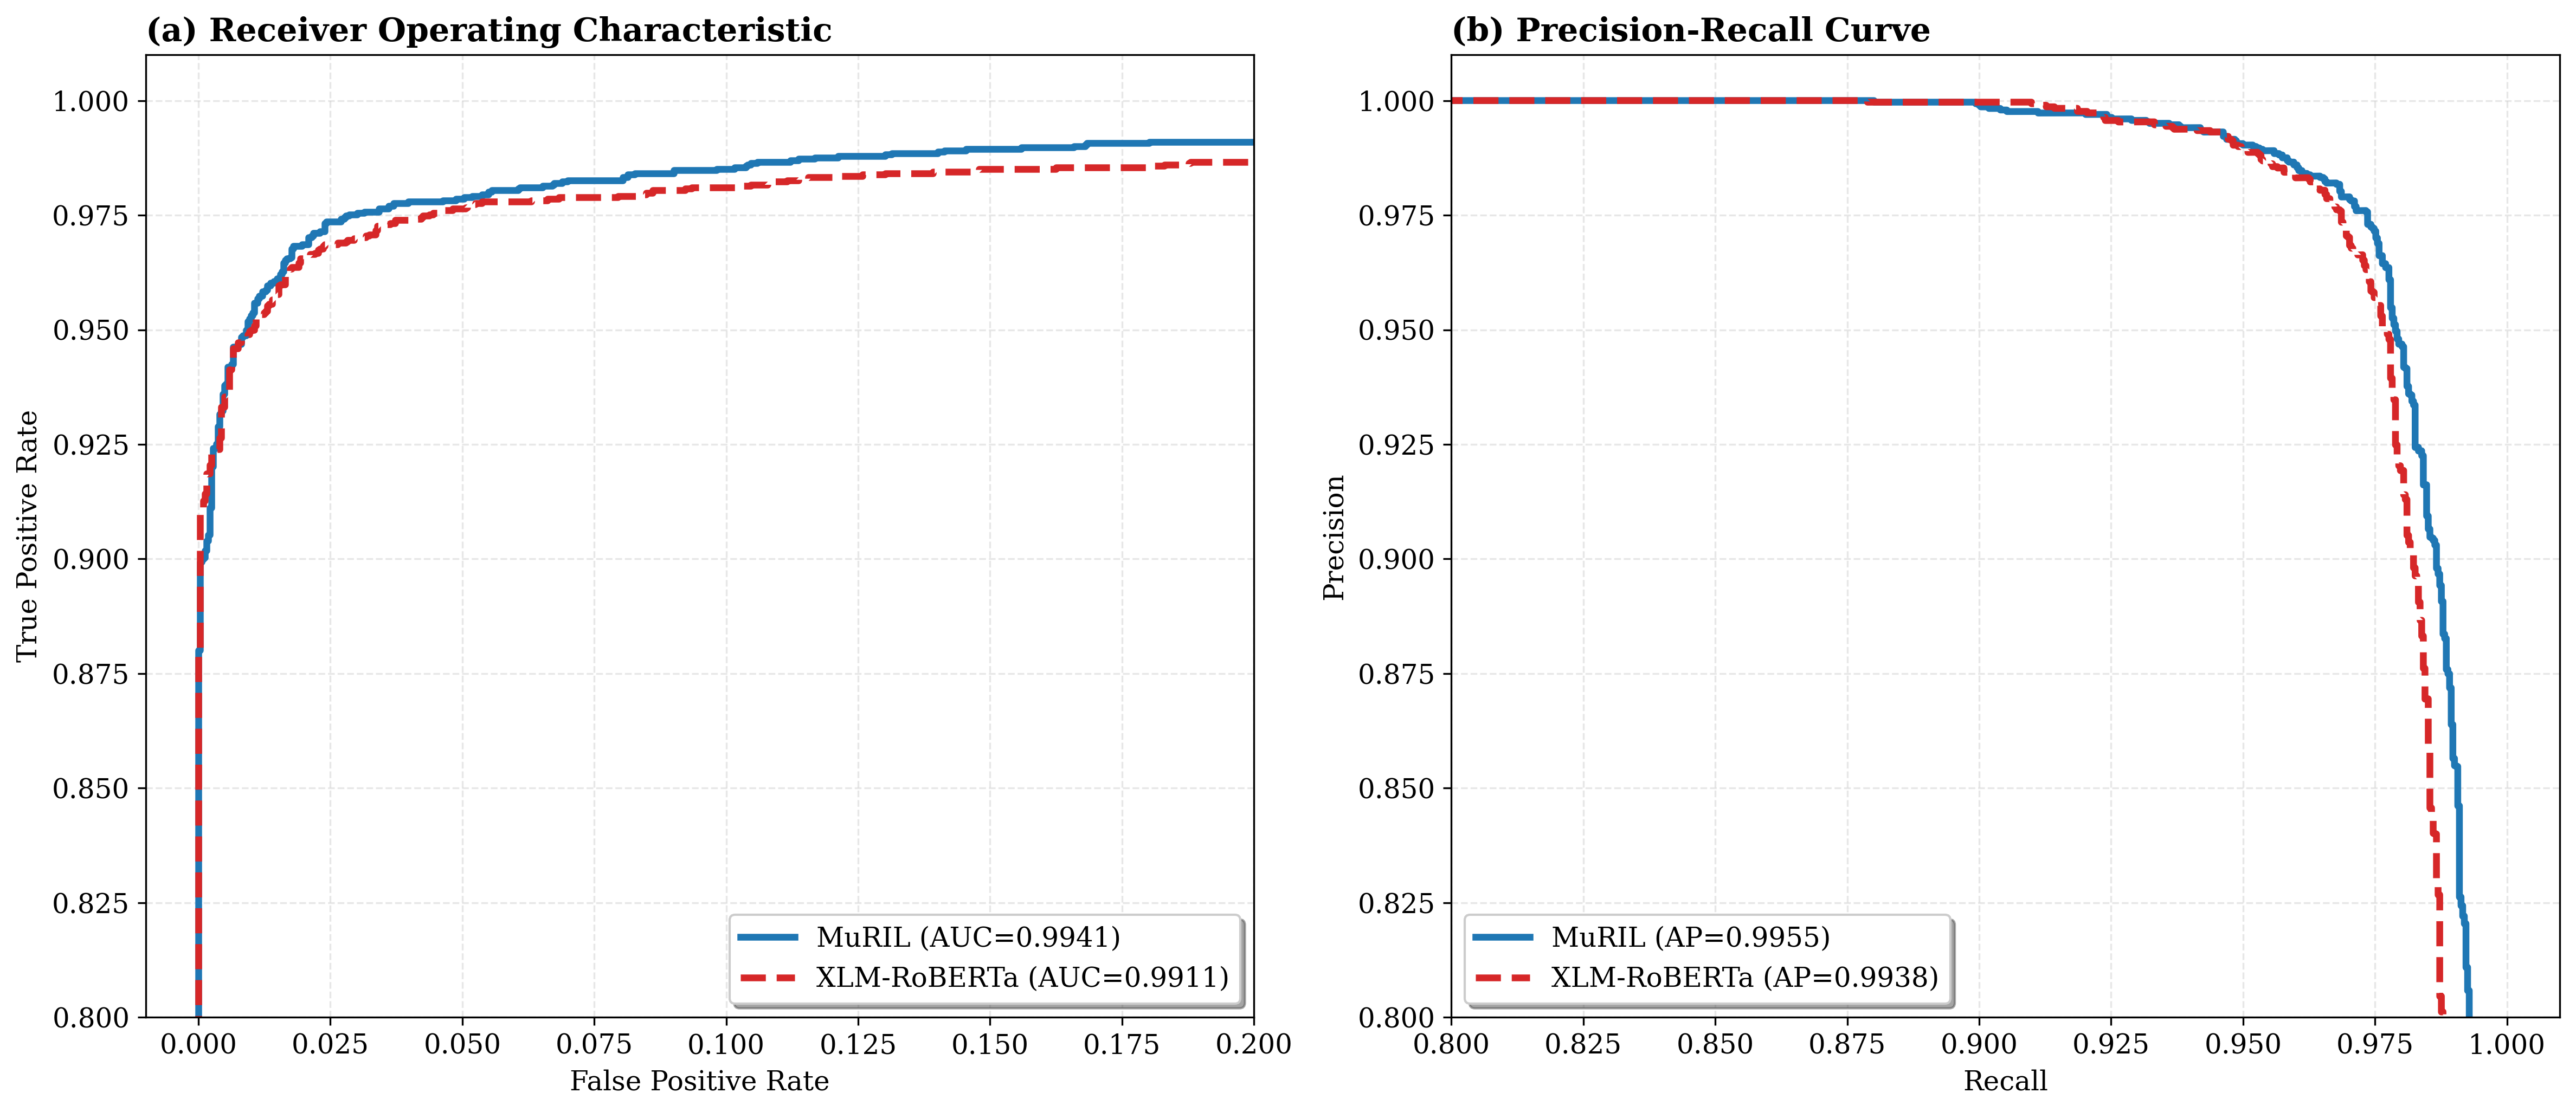

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
styles = ['-', '--'] 
colors = ['#1f77b4', '#d62728'] 

for (name, data), style, color in zip(results.items(), styles, colors):
    fpr, tpr, _ = roc_curve(y_true, data["prob"])
    ax1.plot(fpr, tpr, linestyle=style, color=color, lw=3, label=f'{name} (AUC={auc(fpr, tpr):.4f})')
    
    prec, rec, _ = precision_recall_curve(y_true, data["prob"])
    ap = average_precision_score(y_true, data["prob"])
    ax2.plot(rec, prec, linestyle=style, color=color, lw=3, label=f'{name} (AP={ap:.4f})')

ax1.set_title('(a) Receiver Operating Characteristic', loc='left', fontweight='bold')
ax1.set_xlim([-0.01, 0.2]) 
ax1.set_ylim([0.8, 1.01])  
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right", frameon=True, shadow=True)

ax2.set_title('(b) Precision-Recall Curve', loc='left', fontweight='bold')
ax2.set_xlim([0.8, 1.01]) 
ax2.set_ylim([0.8, 1.01]) 
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left", frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("Detailed_Performance_Curves.pdf")
plt.show()


In [14]:
for name, data in results.items():
    print(f"\n" + "="*60)
    print(f"PERFORMANCE REPORT: {name.upper()}")
    print("="*60)
    print(classification_report(y_true, data["pred"], target_names=['Ham', 'Spam'], digits=4))


PERFORMANCE REPORT: MURIL
              precision    recall  f1-score   support

         Ham     0.9690    0.9798    0.9744      3219
        Spam     0.9796    0.9686    0.9741      3219

    accuracy                         0.9742      6438
   macro avg     0.9743    0.9742    0.9742      6438
weighted avg     0.9743    0.9742    0.9742      6438


PERFORMANCE REPORT: XLM-ROBERTA
              precision    recall  f1-score   support

         Ham     0.9640    0.9826    0.9732      3219
        Spam     0.9823    0.9633    0.9727      3219

    accuracy                         0.9730      6438
   macro avg     0.9731    0.9730    0.9730      6438
weighted avg     0.9731    0.9730    0.9730      6438


PERFORMANCE REPORT: ENSEMBLE
              precision    recall  f1-score   support

         Ham     0.9671    0.9848    0.9758      3219
        Spam     0.9845    0.9664    0.9754      3219

    accuracy                         0.9756      6438
   macro avg     0.9758    0.9756    0